# Phase 4 — Sales EDA

Revenue trend, product distribution, regional differences, seasonality (incl. a formal Ramadan-vs-non-Ramadan hypothesis test), discount relationships, and customer segments.

**Prerequisite:** `make etl` has been run and `DATABASE_URL` points at the populated warehouse (see `etl/README.md`).

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from src.eda import data_access, stats_tests

sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")


In [2]:
from src.eda.ramadan import label_ramadan

sales = data_access.load_sales_detail()
sales.shape

(293169, 21)

## 1. Revenue trend

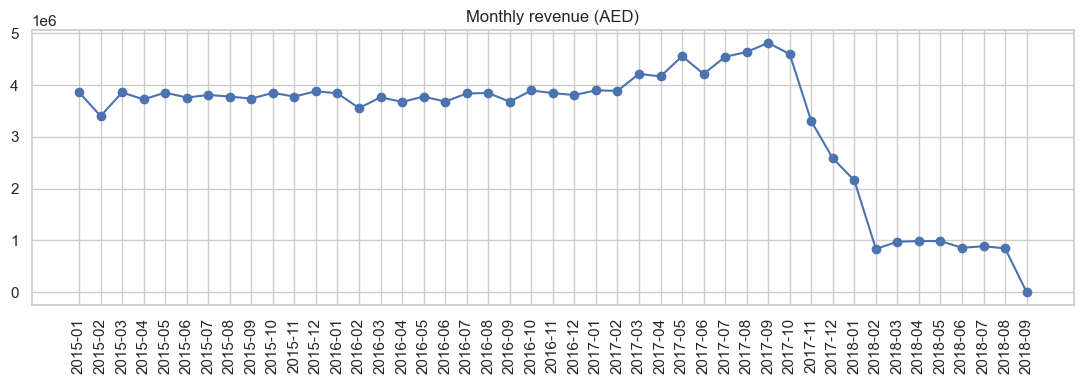

In [3]:
monthly = data_access.run_sql_file('02_sales/03_revenue_by_month.sql')
monthly['period'] = monthly['year'].astype(str) + '-' + monthly['month'].astype(str).str.zfill(2)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(monthly['period'], monthly['revenue_aed'], marker='o')
ax.set_title('Monthly revenue (AED)')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

## 2. Product distribution

Line-item revenue is heavily right-skewed (a few big-ticket items, many cheap ones) — shown here on a log scale, which is standard for monetary distributions like this.

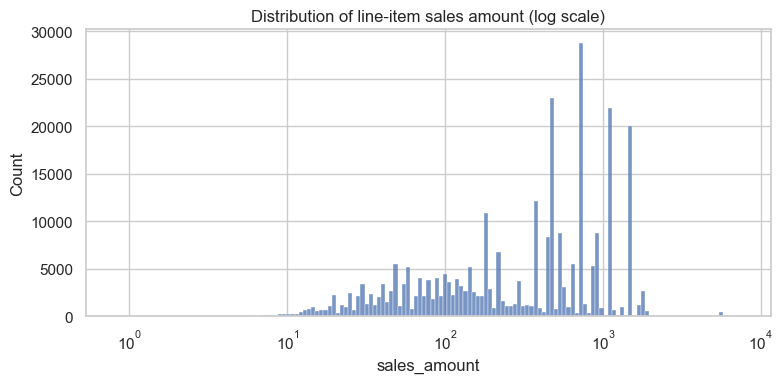

In [4]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(sales['sales_amount'].clip(lower=0.01), log_scale=True, ax=ax)
ax.set_title('Distribution of line-item sales amount (log scale)')
plt.tight_layout()
plt.show()

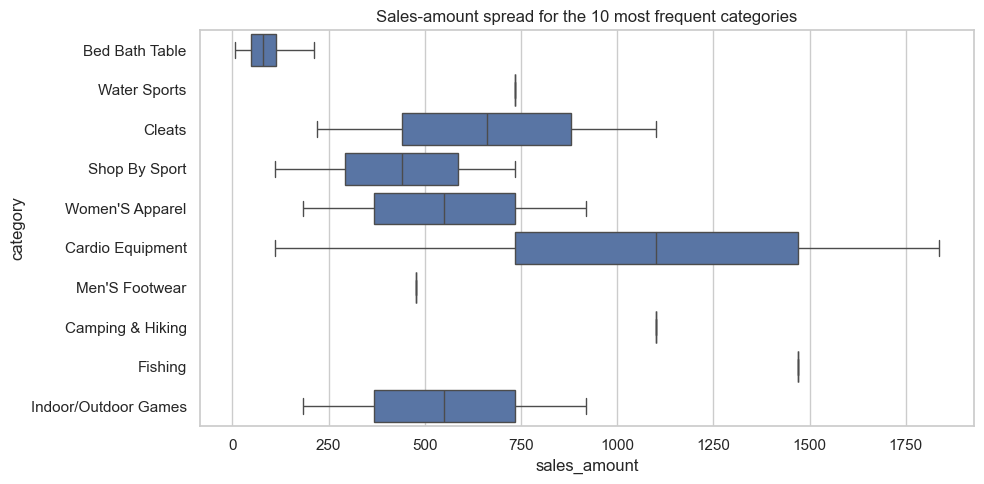

In [5]:
top_categories = sales['category'].value_counts().head(10).index
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(
    data=sales[sales['category'].isin(top_categories)],
    x='sales_amount', y='category', ax=ax, showfliers=False,
)
ax.set_title('Sales-amount spread for the 10 most frequent categories')
plt.tight_layout()
plt.show()

## 3. Regional differences

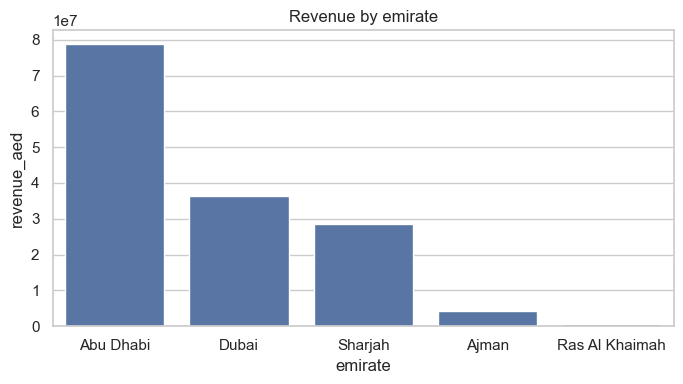

,emirate,order_count,revenue_aed
0,Abu Dhabi,67000,"78,668,619.87"
1,Dubai,74452,"36,480,227.67"
2,Sharjah,16315,"28,583,351.78"
3,Ajman,2806,"4,232,286.75"
4,Ras Al Khaimah,3845,"583,313.00"


In [6]:
by_region = data_access.run_sql_file('02_sales/01_revenue_by_region.sql')
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=by_region, x='emirate', y='revenue_aed', ax=ax)
ax.set_title('Revenue by emirate')
plt.tight_layout()
plt.show()
by_region

## 4. Seasonality

First, the plain month-of-year pattern (pooling all years), then the formal test: does demand actually differ between Ramadan and non-Ramadan days?

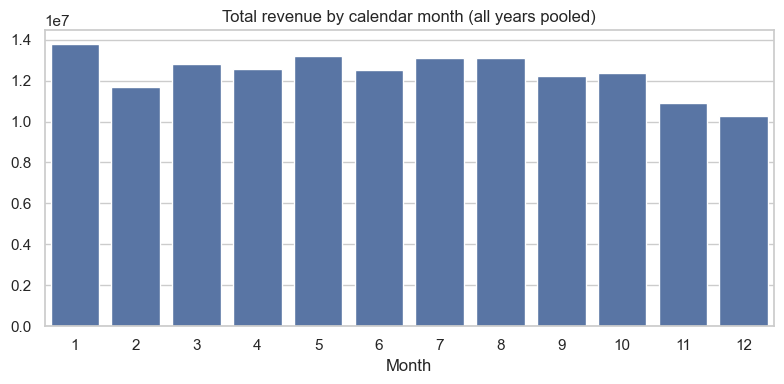

In [7]:
month_of_year = sales.groupby('month')['sales_amount'].sum()
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(x=month_of_year.index, y=month_of_year.values, ax=ax)
ax.set_title('Total revenue by calendar month (all years pooled)')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

### Hypothesis test — Ramadan vs. non-Ramadan demand

Demand is measured as **total daily revenue** (not line-item revenue — the unit of comparison is "a day", so line items must be aggregated to daily totals first, or every day would be represented by dozens of correlated line-item observations instead of one).

Ramadan date ranges are real, published Gregorian equivalents of the Islamic calendar for 2015-2018 (`src/eda/ramadan.py`), not fabricated — see that module's docstring for why this is different from the `is_uae_holiday`/`season_label` columns left unset in `etl/transform/dates.py`.

In [8]:
daily = sales.groupby('order_date')['sales_amount'].sum().reset_index()
daily['season'] = label_ramadan(daily['order_date'])

ramadan_days = daily.loc[daily['season'] == 'Ramadan', 'sales_amount'].to_numpy()
non_ramadan_days = daily.loc[daily['season'] == 'Non-Ramadan', 'sales_amount'].to_numpy()

result = stats_tests.compare_two_groups(
    ramadan_days, non_ramadan_days,
    question='Does daily demand differ between Ramadan and non-Ramadan days?',
    h0='Mean/median daily revenue is the same on Ramadan days as on non-Ramadan days.',
    h1='Mean/median daily revenue on Ramadan days differs from non-Ramadan days.',
)
print(result.summary())

Q: Does daily demand differ between Ramadan and non-Ramadan days?
H0: Mean/median daily revenue is the same on Ramadan days as on non-Ramadan days.
H1: Mean/median daily revenue on Ramadan days differs from non-Ramadan days.
Test: Mann-Whitney U | statistic=69199.0000 | p=0.4878 | rank-biserial r=0.0386
Result: fail to reject H0 at alpha=0.05 — group A's mean/median is lower than group B's, a not statistically significant difference (|rank-biserial r|=0.039).


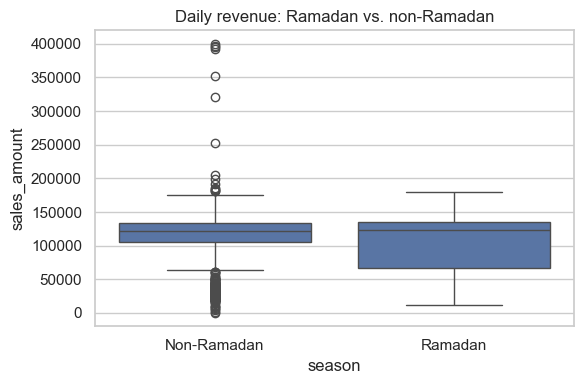

In [9]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.boxplot(data=daily, x='season', y='sales_amount', ax=ax)
ax.set_title('Daily revenue: Ramadan vs. non-Ramadan')
plt.tight_layout()
plt.show()

## 5. Discount relationships

Only DataCo carries real discount data (`Order Item Discount`) — Olist has none, so `discount_amount_aed` is always 0 there and those rows are excluded from this section rather than diluting it with structural zeros.

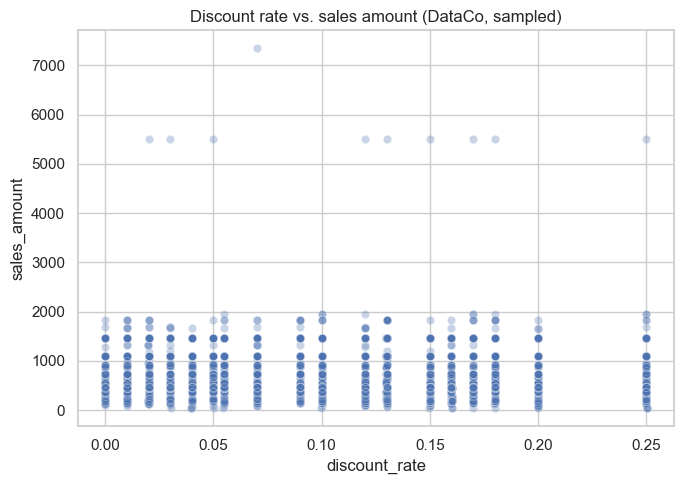

Spearman correlation (discount rate vs. sales amount): r=-0.015, p=1.378e-10


In [10]:
from scipy.stats import spearmanr

dataco_sales = sales[sales['source_system'] == 'dataco'].copy()
dataco_sales['discount_rate'] = dataco_sales['discount'] / (
    dataco_sales['unit_price'] * dataco_sales['quantity']
).replace(0, pd.NA)

fig, ax = plt.subplots(figsize=(7, 5))
sns.scatterplot(
    data=dataco_sales.sample(min(3000, len(dataco_sales)), random_state=42),
    x='discount_rate', y='sales_amount', alpha=0.3, ax=ax,
)
ax.set_title('Discount rate vs. sales amount (DataCo, sampled)')
plt.tight_layout()
plt.show()

valid = dataco_sales.dropna(subset=['discount_rate'])
corr, p = spearmanr(valid['discount_rate'], valid['sales_amount'])
print(f'Spearman correlation (discount rate vs. sales amount): r={corr:.3f}, p={p:.4g}')

## 6. Customer segments

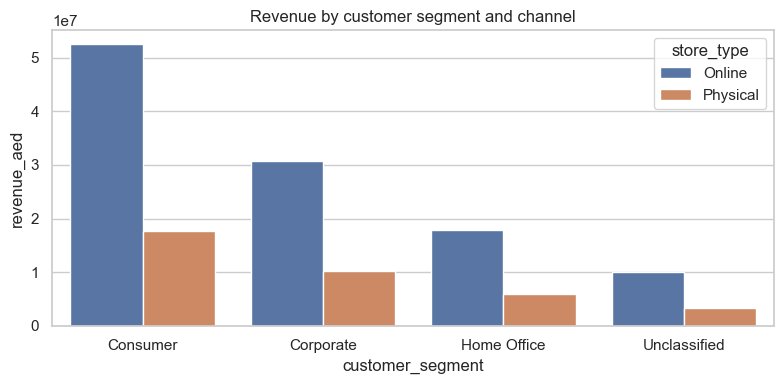

,customer_segment,store_type,customer_count,revenue_aed
0,Consumer,Online,9592,"52,456,999.85"
1,Corporate,Online,5616,"30,829,415.62"
2,Home Office,Online,3285,"17,930,040.87"
3,Consumer,Physical,7022,"17,672,372.51"
4,Corporate,Physical,4056,"10,186,606.71"
5,Unclassified,Online,76165,"10,112,846.69"
6,Home Office,Physical,2469,"6,016,663.23"
7,Unclassified,Physical,26706,"3,342,853.59"


In [11]:
by_segment = data_access.run_sql_file('06_customer/01_customer_segment_breakdown.sql')
fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=by_segment, x='customer_segment', y='revenue_aed', hue='store_type', ax=ax)
ax.set_title('Revenue by customer segment and channel')
plt.tight_layout()
plt.show()
by_segment